In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from itertools import product

import sys

from pathlib import Path
nb_dir = Path.cwd()
help_func_path = os.path.join(nb_dir,'helper_code')

sys.path.append(help_func_path) 

from plotting_functions import scatter_helper, plot_3d_scatters
from saving_functions import save_dataset,delete_dataset

In [5]:
from scipy import stats

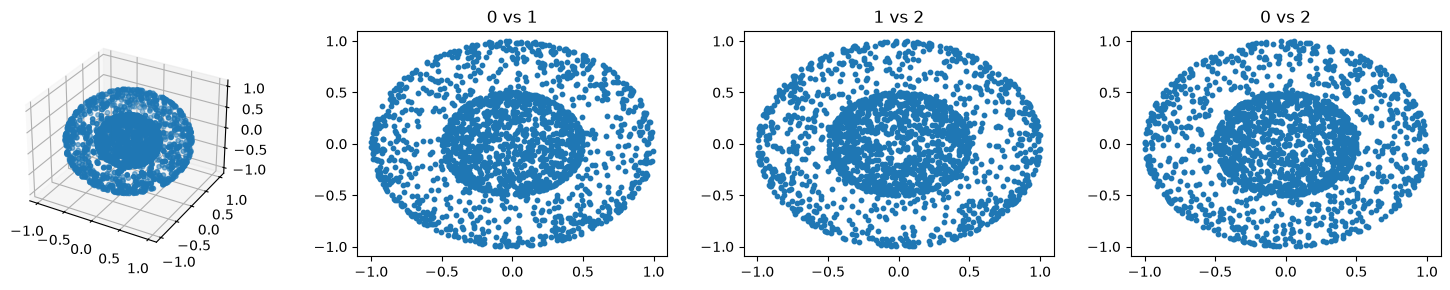

In [6]:
rng = np.random.default_rng()

uniform_sphere_dist = stats.uniform_direction(3)

unit_vectors1 = uniform_sphere_dist.rvs(1000, random_state=rng)
unit_vectors2 = uniform_sphere_dist.rvs(1000, random_state=rng)*0.5

plot_3d_scatters(np.vstack([unit_vectors1,unit_vectors2]),title_name='')

In [27]:
# n_samples = 1000
# n_features = 3
# n_shells, max_radius = 7, 10
# jitter_std = 0.1
# seed = 0

def concentric_shell_sample(n_samples,n_features,n_shells,max_radius=1,jitter_std=0.1,seed=0):
    rng = np.random.default_rng(seed)
    sphere = stats.uniform_direction(n_features)

    spacing = max_radius / n_shells
    num_sample_per_shell = n_samples // n_shells
    num_sample_zero = num_sample_per_shell + (n_samples - num_sample_per_shell * n_shells) # add the extras to 0th index

    X, y = [], []

    for k in range(0, n_shells):
        tmp_shell_num_sample = num_sample_per_shell
        if k == 0:
            tmp_shell_num_sample = num_sample_zero 
            
        jitter = rng.normal(0, jitter_std, (tmp_shell_num_sample, n_features))
        X.append(sphere.rvs(tmp_shell_num_sample, random_state=rng) * spacing * (k+1) + jitter)
        y += [k] * tmp_shell_num_sample

    X, y = np.vstack(X), np.array(y)
    perm = rng.permutation(len(X))
    return X[perm], y[perm]

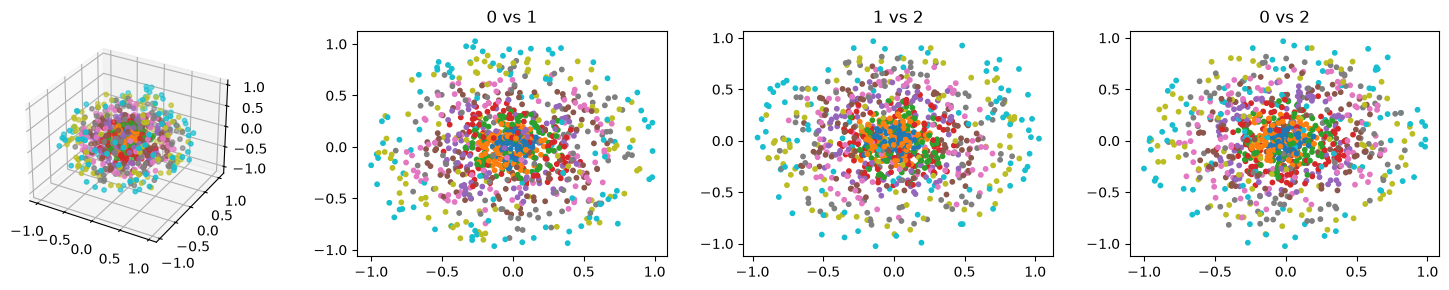

In [28]:
X,y = concentric_shell_sample(1000,3,10,jitter_std=0.05)
plot_3d_scatters(X,y=y,title_name='')

In [29]:
data_gen_name = 'concentric_shells'
category_lst = ['density']

n_samples_lst = [1000,10000]
n_features_lst = [10,100,1000,10000]
random_seeds_lst = [82930,29]

n_shells_lst = [2,4,6,8]
max_r = 1
jitter_std_lst = [0.01,0.05,0.1] #could make it scale by n_shells and n_features for future

for jitter_std in jitter_std_lst:
    
    for n_shells in n_shells_lst:
        
        for n_samples, n_features in product(n_samples_lst, n_features_lst):
            
            print(n_samples, n_features)

            for sample_num,seed in enumerate(random_seeds_lst):
                
                X,y = concentric_shell_sample(n_samples,n_features,n_shells,max_radius=max_r,jitter_std=jitter_std,seed=seed)

                params_dict = {
                    'n_shells' : n_shells,
                    'max_radius' : 1,
                    'jitter_std' : jitter_std
                }
                
                extra_arr = {
                    'sphere_labels' : y
                }
                                
                try:
                    save_dataset(X, 
                                generator=data_gen_name,
                                params=params_dict,
                                seed=seed,
                                category=category_lst,
                                extra_arrays=extra_arr, 
                                root='../all_data/')

                except:
                    print('error?')

1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000
1000 10
1000 100
1000 1000
1000 10000
10000 10
10000 100
10000 1000
10000 10000


In [ ]:

## OLD FUNCTION, HERE JUST FOR REFERENCE
## ONLY GENERATES N_FEAT = 3
# def noisy_concentric_spheres(n_samples=1000,n_spheres=4,noise=0.2, center=(0, 0, 0),random_state=None, radii_arr=None):
    
#     if radii_arr is None:
#         scale_factor = 1
#         min_r = 1*scale_factor
#         radii_arr = np.linspace(min_r, n_spheres*scale_factor,n_spheres)

#     if isinstance(noise, float):
#         # num_center = 1
#         pass
#     elif isinstance(noise, list):
#         assert n_spheres == len(noise)
#     else:
#         # raise error
#         return

#     # print(len(radii_arr))
#     assert len(radii_arr) == n_spheres

#     n_samples_per_shell = int(n_samples / n_spheres)
#     rng = np.random.default_rng(seed=random_state)
#     if isinstance(noise, float):
#         # num_center = 1
#         pass
#     elif isinstance(noise, list):
#         assert n_spheres == len(noise)
#     else:
#         # raise error
#         return

#     X_list = []

#     for i, r in enumerate(radii_arr):
        
#         if isinstance(noise,float):
#             noise_r = noise
#         else:
#             noise_r = noise[i]

#         # sample spherical coords
#         theta = rng.uniform(0, 2 * np.pi, n_samples_per_shell)
#         phi = np.arccos(rng.uniform(-1, 1, n_samples_per_shell))
                
#         r_noisy_x = r + rng.normal(0, noise_r, n_samples_per_shell)
#         r_noisy_y = r + rng.normal(0, noise_r, n_samples_per_shell)
#         r_noisy_z = r + rng.normal(0, noise_r, n_samples_per_shell)

#         # convert to feature vector
#         x = r_noisy_x * np.sin(phi) * np.cos(theta)
#         y = r_noisy_y * np.sin(phi) * np.sin(theta)
#         z = r_noisy_z * np.cos(phi)
        
#         shell_points = np.stack([x, y, z], axis=1)
#         X_list.append(shell_points)
    
#     X = np.vstack(X_list)


#     return X

# noisy_concentric_spheres(1000,4)

array([[-0.27287117, -1.10311978,  0.20455978],
       [-0.47333842,  0.10384445, -0.64995979],
       [ 0.15083919,  0.88548263,  0.30617674],
       ...,
       [ 0.0728739 , -1.68091901,  3.79037142],
       [ 2.09228233,  2.76227705, -2.04773462],
       [-2.65605522, -0.6082335 , -2.53600475]], shape=(1000, 3))